<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
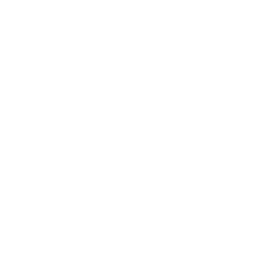
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Perfil de Risco de Clientes via Discriminação Canônica</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Serviços Financeiros / Análise de Risco de Crédito &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Três grupos de status de empréstimo em uma carteira de hipotecas de consumo — **inadimplente**, **em dia** e **quitado antecipadamente** — diferem em várias dimensões de saúde financeira ao mesmo tempo, o que torna qualquer índice isolado um sinal de risco fraco. Este notebook aplica **PROC CANDISC** (análise discriminante canônica) a uma amostra de revisão de risco de 100 clientes, condensando seis índices financeiros correlacionados em duas dimensões canônicas que maximizam a separação entre os três grupos de status.

A primeira dimensão canônica carrega quase toda a separação entre grupos — correlação canônica **0.958**, compartilhando **91.8%** de sua variância com a associação ao grupo — e ordena os tomadores de forma clara, dos inadimplentes em um extremo aos quitados antecipadamente no outro. A segunda dimensão (correlação canônica **0.503**, ao quadrado **0.254**) acrescenta um contraste secundário liderado pelo histórico de inadimplência e pela alavancagem. As distâncias de Mahalanobis ao quadrado confirmam que os centroides **DEFAULT** e **PREPAID** são o par mais amplamente separado (**75.3**), com **CURRENT** situado entre eles (34.3 de DEFAULT, 10.1 de PREPAID). Os escores canônicos resultantes formam um índice de risco composto e compacto, adequado para segmentação de carteira e calibração de scorecard.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| WORK.LOAN_PROFILES | Índices financeiros e métricas comportamentais sintéticas de clientes, rotulados por status de empréstimo, extraídos como uma amostra equilibrada de revisão de risco | 100 |

A amostra sobre-representa deliberadamente contas inadimplentes e quitadas antecipadamente (uma extração no estilo caso–controle) para que cada grupo de status seja grande o suficiente para estimar uma estrutura de covariância intragrupo estável para a análise discriminante.

---

In [1]:
/* --------------------------------------------------------
   Gerar uma amostra sintética de revisão de risco de
   clientes de crédito. Três grupos de estado (DEFAULT /
   CURRENT / PREPAID) são sobre-amostrados em direção às
   caudas de risco para que cada classe seja suficientemente
   grande para uma estimativa estável da covariância
   intra-grupo.
   -------------------------------------------------------- */
DADOS work.loan_profiles;
    CHAMAR streaminit(42);
    COMPRIMENTO loan_status $10 vintage $7 customer_id $12;
    VETOR statuses[3] $10 _temporary_ ('DEFAULT' 'CURRENT' 'PREPAID');
    VETOR vintages[4] $7 _temporary_ ('2022-Q1' '2022-Q3' '2023-Q1' '2023-Q3');
    FAZER i = 1 ATÉ 20000;
        customer_id = cat('CUST-', PUT(i, z6.));
        vintage = vintages[int(rand('uniform') * 4) + 1];
        status_prob = rand('uniform');
        SE status_prob < 0.30 ENTÃO status_idx = 1;       /* DEFAULT */
        SENÃO SE status_prob < 0.70 ENTÃO status_idx = 2;  /* CURRENT */
        SENÃO status_idx = 3;                             /* PREPAID */
        loan_status = statuses[status_idx];
        /* Rácios financeiros separam os três grupos de estado */
        SE loan_status = 'DEFAULT' ENTÃO FAZER;
            dti_ratio          = rand('normal', 0.58, 0.12);
            ltv_ratio          = rand('normal', 0.92, 0.10);
            payment_to_income  = rand('normal', 0.42, 0.08);
            credit_utilization = rand('normal', 0.85, 0.10);
            months_delinquent  = int(rand('exponential') * 4) + 1;
            savings_balance    = rand('exponential') * 4000 + 200;
        FIM;
        SENÃO SE loan_status = 'CURRENT' ENTÃO FAZER;
            dti_ratio          = rand('normal', 0.35, 0.10);
            ltv_ratio          = rand('normal', 0.78, 0.09);
            payment_to_income  = rand('normal', 0.28, 0.07);
            credit_utilization = rand('normal', 0.45, 0.15);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 8000 + 200;
        FIM;
        SENÃO FAZER;
            dti_ratio          = rand('normal', 0.22, 0.07);
            ltv_ratio          = rand('normal', 0.60, 0.12);
            payment_to_income  = rand('normal', 0.20, 0.05);
            credit_utilization = rand('normal', 0.25, 0.12);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 16000 + 500;
        FIM;
        /* Arredondar e restringir rácios a intervalos válidos */
        dti_ratio          = round(dti_ratio, 0.001);
        ltv_ratio          = round(ltv_ratio, 0.001);
        payment_to_income  = round(payment_to_income, 0.001);
        credit_utilization = round(credit_utilization, 0.001);
        savings_balance    = round(savings_balance, 0.01);
        SE dti_ratio < 0.05 ENTÃO dti_ratio = 0.05;
        SE dti_ratio > 0.99 ENTÃO dti_ratio = 0.99;
        SE ltv_ratio < 0.10 ENTÃO ltv_ratio = 0.10;
        SE ltv_ratio > 1.20 ENTÃO ltv_ratio = 1.20;
        SE credit_utilization < 0.01 ENTÃO credit_utilization = 0.01;
        SE credit_utilization > 0.99 ENTÃO credit_utilization = 0.99;
        RÓTULO loan_status='Estado do Empréstimo'
              vintage='Safra'
              dti_ratio='Rácio Dívida/Rendimento'
              ltv_ratio='Rácio Empréstimo/Valor'
              payment_to_income='Pagamento/Rendimento'
              credit_utilization='Utilização de Crédito'
              savings_balance='Saldo de Poupança'
              months_delinquent='Meses em Incumprimento'
              customer_id='ID do Cliente';
        SAÍDA;
    FIM;
    REMOVER i status_prob status_idx;
EXECUTAR;


NOTE: DATA work.loan_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.loan_profiles (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  7.41 seconds
  cpu   7.41 seconds


---

### Perfis de referência dos grupos

Antes de condensar os índices, resuma como os três grupos de status diferem uma variável de cada vez e confirme a composição da amostra entre as safras de originação.

                              Distribuições de Rácios Financeiros por Estado do Empréstimo                              

                                                  The MEANS Procedure

                                Analysis Variable : dti_ratio Rácio Dívida/Rendimento

        Estado do Empréstimo           N Obs           Mean        Std Dev
        ------------------------------------------------------------------
        CURRENT                           46          0.331          0.112
        DEFAULT                           29          0.570          0.114
        PREPAID                           25          0.216          0.056
        ------------------------------------------------------------------

                                 Analysis Variable : ltv_ratio Rácio Empréstimo/Valor

        Estado do Empréstimo           N Obs           Mean        Std Dev
        ------------------------------------------------------------------
        CURRENT                 


NOTE: Option TITLE changed to Distribuições de Rácios Financeiros por Estado do Empréstimo.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: Option TITLE changed to Composição da Amostra por Safra e Estado do Empréstimo.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_vintage_loan_status.spec.json
NOTE: PROC FREQ statement used.


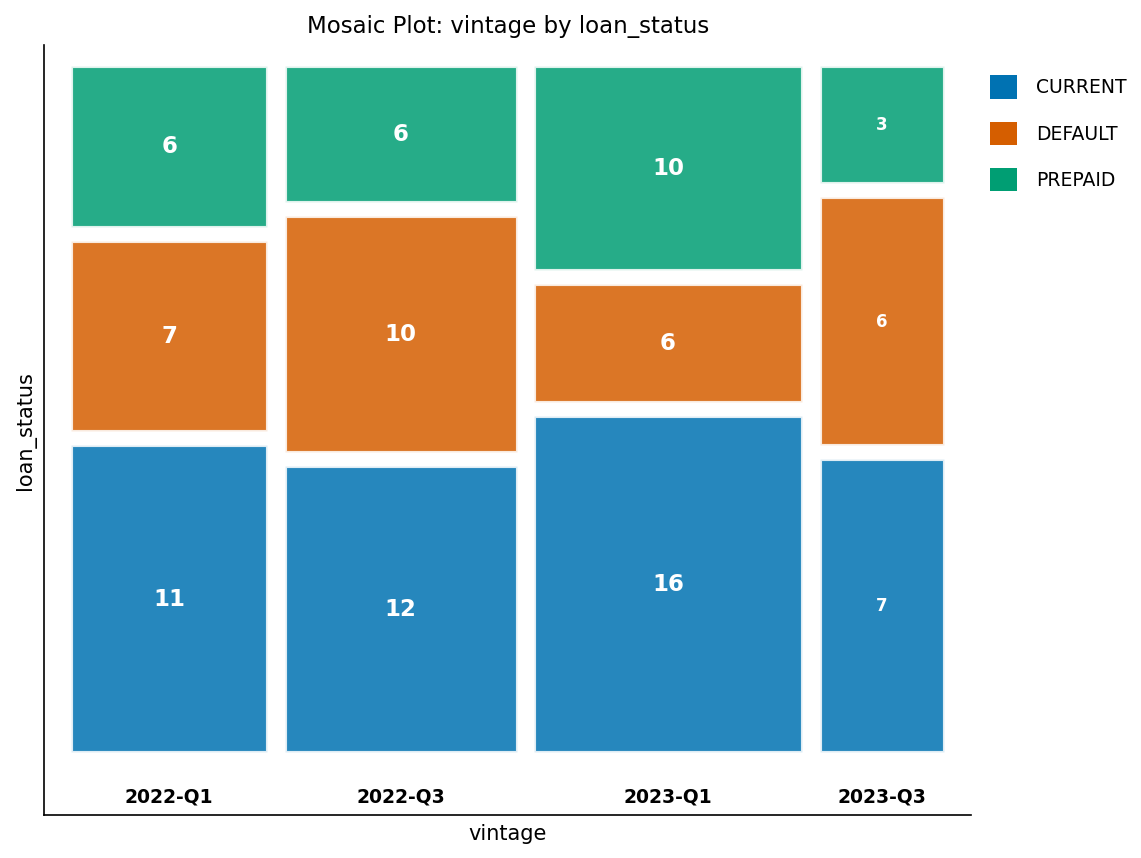

In [2]:
/* --------------------------------------------------------
   Distribuições de base dos rácios financeiros por estado
   -------------------------------------------------------- */
TÍTULO 'Distribuições de Rácios Financeiros por Estado do Empréstimo';
PROCEDIMENTO MÉDIAS DADOS=work.loan_profiles n mean std maxdec=3;
    CLASSE loan_status;
    VARIÁVEL dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
EXECUTAR;

/* --------------------------------------------------------
   Composição da amostra por safra e estado
   -------------------------------------------------------- */
TÍTULO 'Composição da Amostra por Safra e Estado do Empréstimo';
PROCEDIMENTO FREQUÊNCIAS DADOS=work.loan_profiles;
    TABLES vintage * loan_status / nocum nopercent;
EXECUTAR;

---

### Análise discriminante canônica

Ajuste um único modelo discriminante canônico agrupado para todos os 100 clientes. `OUT=` grava os escores canônicos por cliente, `OUTSTAT=` captura a estrutura canônica, os centroides das classes e as distâncias de Mahalanobis ao quadrado, e `DISTANCE` solicita as distâncias entre grupos. O procedimento anunciado aqui é exatamente o que é executado: **PROC CANDISC**.

                           Discriminação Canónica de Risco dos Grupos de Estado do Empréstimo                           




NOTE: ODS OUTPUT: CANONICALCORRELATIONS -> can_corr
NOTE: Option TITLE changed to Discriminação Canónica de Risco dos Grupos de Estado do Empréstimo.
NOTE: PROC CANDISC data=work.loan_profiles ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 100
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   CURRENT: 46
NOTE:   DEFAULT: 29
NOTE:   PREPAID: 25
NOTE: Canonical Correlations:
NOTE:   Can1: 0.958136
NOTE:   Can2: 0.503509
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       11.198645    0.958136            0.918024
NOTE:   Can2        0.339624    0.503509            0.253522
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.061194     46.65      12   184.0   0.0000
NO

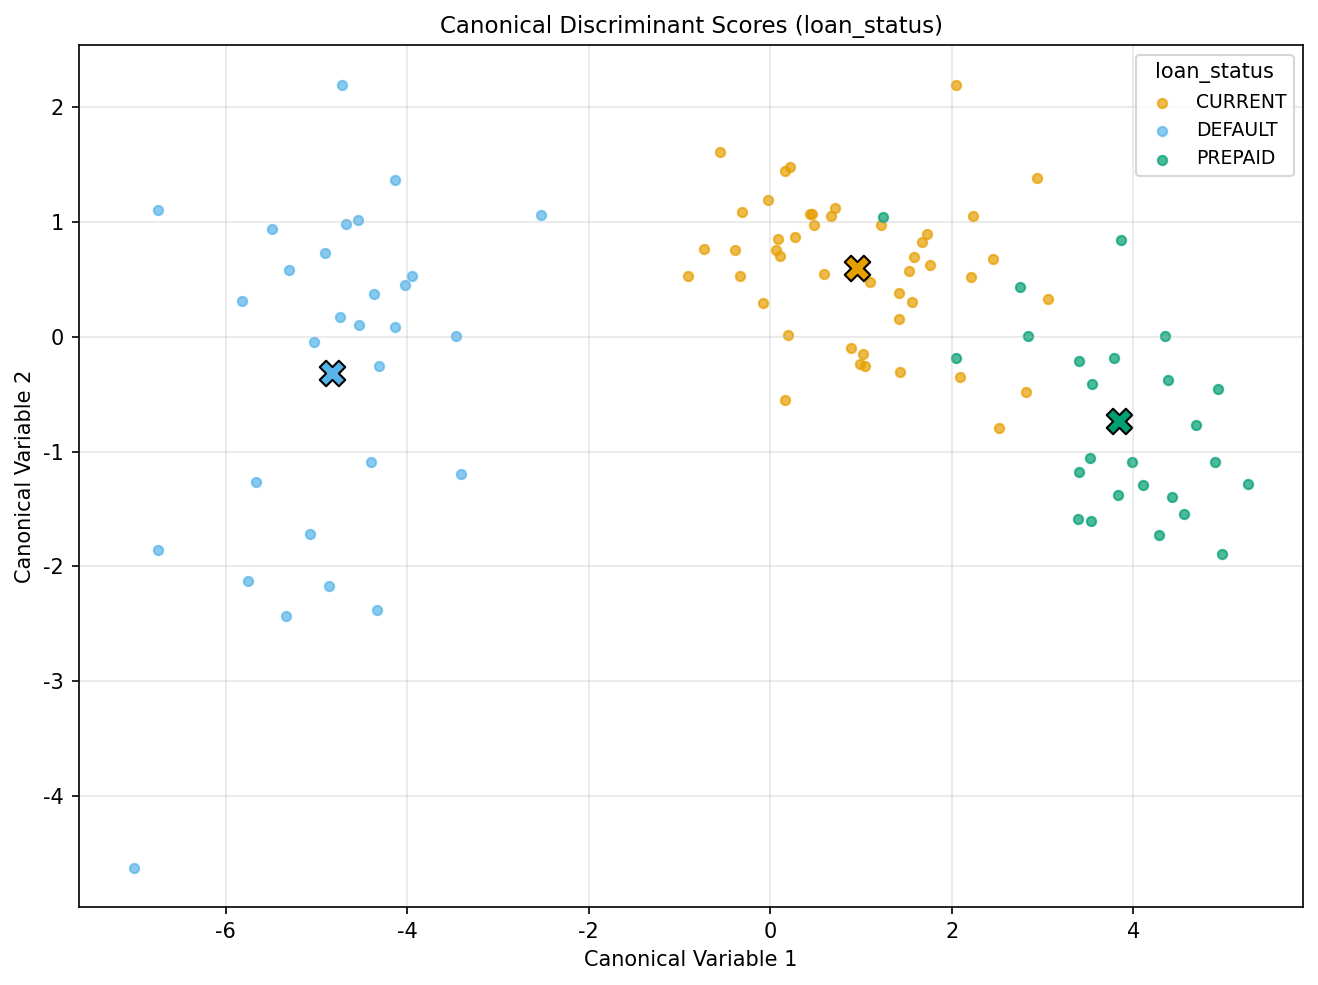

In [3]:
/* --------------------------------------------------------
   Análise discriminante canónica dos grupos de estado.
   OUT=    pontuações canónicas por cliente (Can1, Can2)
   OUTSTAT= estrutura, médias de classe, distâncias de Mahalanobis
   -------------------------------------------------------- */
ODS SAÍDA CanonicalCorrelations=work.can_corr;

TÍTULO 'Discriminação Canónica de Risco dos Grupos de Estado do Empréstimo';
PROCEDIMENTO CANDISC DADOS=work.loan_profiles
    out=work.risk_scores
    OUTSTAT=work.can_stat
    ncan=2
    distance;
    CLASSE loan_status;
    VARIÁVEL dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
EXECUTAR;

ODS SAÍDA CLOSE;

---

### Correlações canônicas

Quanto da separação entre os três grupos cada dimensão canônica captura.

In [4]:
TÍTULO 'Correlações Canónicas';
PROCEDIMENTO IMPRIMIR DADOS=work.can_corr noobs;
EXECUTAR;

                                                 Correlações Canónicas                                                  


CANONICAL_VARIABLE  CANONICAL_CORRELATION  SQUARED_CANONICAL_CORRELATION     EIGENVALUE
------------------  ---------------------  -----------------------------  -------------
Can1                         0.9581355246                   0.9180236835  11.1986452089
Can2                          0.503509317                   0.2535216323   0.3396235488




NOTE: Option TITLE changed to Correlações Canónicas.
NOTE: PROC PRINT data=work.can_corr

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


### Estrutura canônica (cargas das variáveis)

A correlação de cada índice financeiro original com as duas dimensões canônicas — é assim que as dimensões são interpretadas.

In [5]:
TÍTULO 'Estrutura Canónica Intra-Classe Combinada';
PROCEDIMENTO IMPRIMIR DADOS=work.can_stat noobs;
    ONDE _type_ = 'STRUCTUR';
    VARIÁVEL _name_ Can1 Can2;
EXECUTAR;

                                       Estrutura Canónica Intra-Classe Combinada                                        


            _NAME_       CAN1       CAN2
------------------  ---------  ---------
dti_ratio           -0.403583  -0.022755
ltv_ratio           -0.369749   0.732657
payment_to_income   -0.304192   0.117008
credit_utilization  -0.595076  -0.056264
savings_balance       0.12558   0.093182
months_delinquent   -0.323965  -0.699884




NOTE: Option TITLE changed to Estrutura Canónica Intra-Classe Combinada.
NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


### Centroides dos grupos e distâncias de Mahalanobis

As médias das classes nos eixos canônicos (os centroides dos grupos) e as distâncias de Mahalanobis ao quadrado entre cada par de grupos — a base para a calibração do escore de risco.

In [6]:
TÍTULO 'Centróides de Grupo (CANMEAN) e Distâncias de Mahalanobis ao Quadrado (DIST)';
PROCEDIMENTO IMPRIMIR DADOS=work.can_stat noobs;
    ONDE _type_ IN ('CANMEAN' 'DIST');
    VARIÁVEL _type_ _name_ Can1 Can2;
EXECUTAR;

                      Centróides de Grupo (CANMEAN) e Distâncias de Mahalanobis ao Quadrado (DIST)                      


 _TYPE_              _NAME_       CAN1       CAN2
-------  ------------------  ---------  ---------
CANMEAN  CURRENT              0.956102    0.59917
CANMEAN  DEFAULT             -4.826727  -0.316237
CANMEAN  PREPAID              3.839776  -0.735639
DIST     CURRENT to DEFAULT  34.279058          .
DIST     CURRENT to PREPAID  10.097273          .
DIST     DEFAULT to PREPAID  75.284092          .




NOTE: Option TITLE changed to Centróides de Grupo (CANMEAN) e Distâncias de Mahalanobis ao Quadrado (DIST).
NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

### Mapa discriminante canônico

Cada cliente representado no espaço canônico bidimensional, colorido por status de empréstimo. Agrupamentos bem separados indicam que os escores canônicos carregam forte informação de grupo.

                               Perfil de Risco de Clientes: Espaço Discriminante Canónico                               




NOTE: Option TITLE changed to Perfil de Risco de Clientes: Espaço Discriminante Canónico.
NOTE: PROC SGPLOT data=work.risk_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


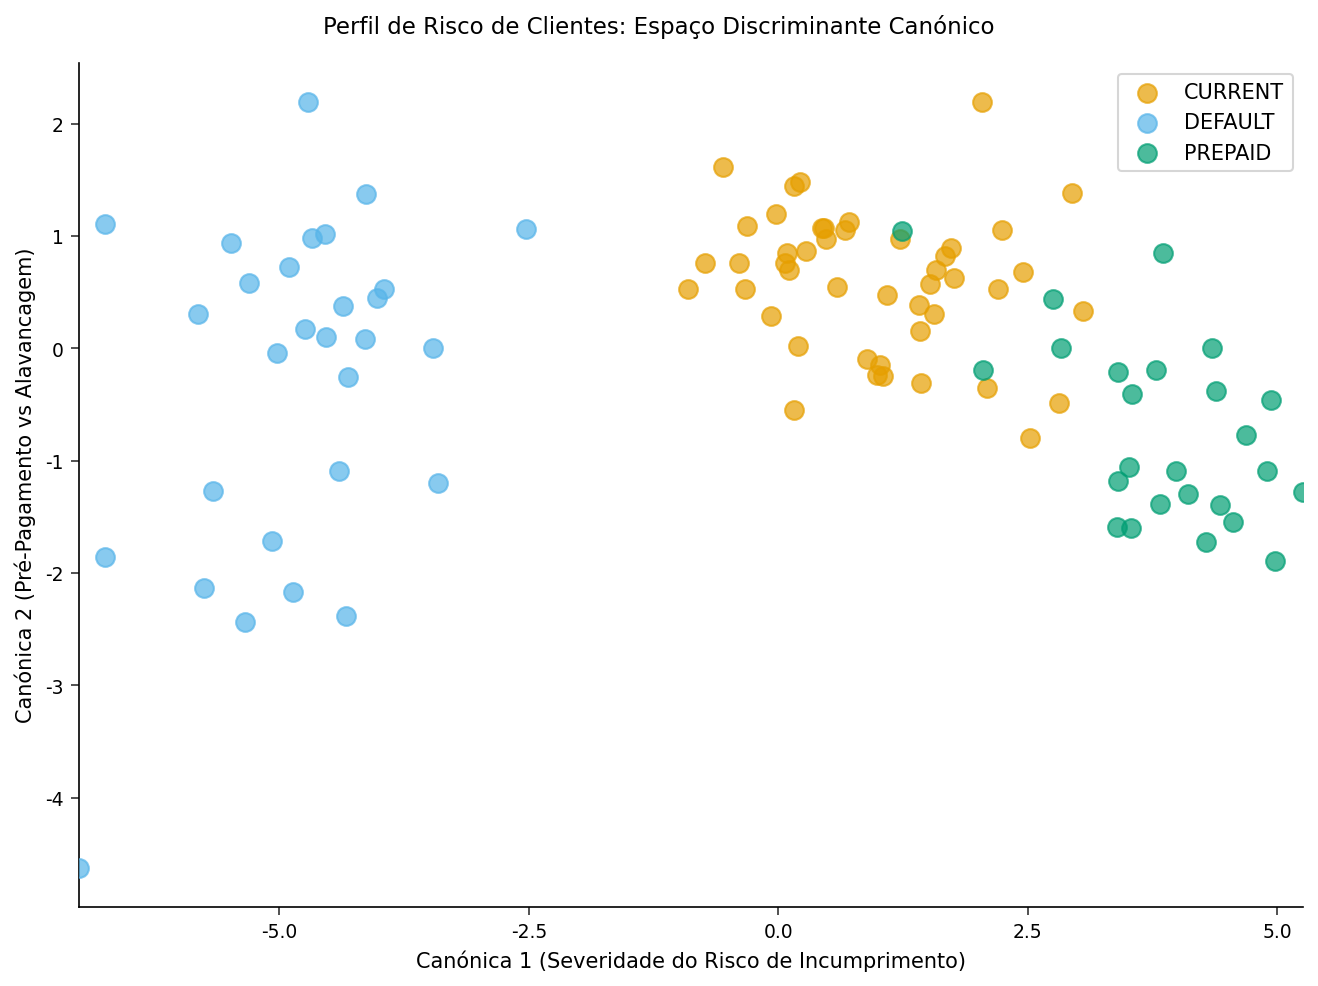

In [7]:
TÍTULO 'Perfil de Risco de Clientes: Espaço Discriminante Canónico';
PROCEDIMENTO SGPLOT DADOS=work.risk_scores;
    SCATTER x=Can1 y=Can2 / GROUP=loan_status
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.3;
    XAXIS RÓTULO='Canónica 1 (Severidade do Risco de Incumprimento)';
    YAXIS RÓTULO='Canónica 2 (Pré-Pagamento vs Alavancagem)';
EXECUTAR;

---

### Interpretação

As duas dimensões canônicas separam nitidamente os três grupos de status de empréstimo dentro desta amostra de 100 clientes (46 em dia, 29 inadimplentes, 25 quitados antecipadamente).

**Dimensão 1 — severidade do risco de inadimplência (correlação canônica 0.958, 91.8% de variância compartilhada).** Este eixo, sozinho, responde pela esmagadora maioria da separação entre grupos (autovalor 11.20 contra 0.34 do segundo eixo). Na estrutura canônica intraclasse agrupada, ele carrega mais fortemente na utilização de crédito (-0.595), na relação dívida-renda (-0.404), no LTV (-0.370), nos meses de inadimplência (-0.324) e na relação pagamento-renda (-0.304) — todas as medidas de alavancagem e de carga apontam na mesma direção. Como as cargas são negativas, escores Can1 baixos (mais negativos) marcam os tomadores de maior risco. Os centroides das classes confirmam isso: as contas inadimplentes situam-se em Can1 = -4.83, as contas em dia em +0.96 e as contas quitadas antecipadamente em +3.84, uma ordenação monotônica clara da pior à melhor saúde de crédito.

**Dimensão 2 — alavancagem versus inadimplência (correlação canônica 0.503).** O segundo eixo contrasta a relação LTV (+0.733) com os meses de inadimplência (-0.700): ele separa os tomadores altamente alavancados, mas em dia, daqueles que carregam inadimplência. Ele refina o quadro dentro de Can1, mas contribui com muito menos separação, como mostram os centroides Can2 quase iguais dos grupos adimplentes (em dia +0.599, quitados antecipadamente -0.736).

**Separação entre grupos.** As distâncias de Mahalanobis ao quadrado entre as médias das classes quantificam as diferenças: DEFAULT-para-PREPAID é a maior, 75.3, DEFAULT-para-CURRENT é 34.3 e CURRENT-para-PREPAID é a menor, 10.1. Os dois grupos adimplentes estão, portanto, mais próximos entre si do que qualquer um deles está do grupo inadimplente, exatamente como um credor esperaria.

**Uso prático.** O primeiro escore canônico se comporta como um índice de risco composto pronto para uso: ele comprime seis índices correlacionados em uma única dimensão bem separada que ordena os clientes do maior ao menor risco de inadimplência. As equipes de carteira podem segmentar em pontos de corte de Can1, e as distâncias de Mahalanobis fornecem uma base fundamentada para atribuir um novo solicitante ao grupo de status mais próximo durante a calibração do scorecard.

---

### Exportação para o mecanismo de scoring

Persista os escores canônicos por cliente e o conjunto de dados de estatísticas canônicas (que carrega os centroides e as distâncias de Mahalanobis) para a calibração de scorecard posterior.

In [8]:
/* --------------------------------------------------------
   Exportar pontuações canónicas de risco e estatísticas canónicas
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.risk_scores
    OUTFILE='customer_risk_canonical_scores.csv'
    DBMS=csv REPLACE;
EXECUTAR;

PROCEDIMENTO EXPORT DADOS=work.can_stat
    OUTFILE='canonical_statistics.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=work.risk_scores outfile=customer_risk_canonical_scores.csv

NOTE: Exported 100 rows to customer_risk_canonical_scores.csv.
NOTE: PROC EXPORT data=work.can_stat outfile=canonical_statistics.csv

NOTE: Exported 31 rows to canonical_statistics.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>